In [22]:
import pandas as pd
import glob

institution_details = pd.read_csv('cc_institution_details.csv')
institution_grads = pd.read_csv('cc_institution_grads.csv')
state_sector_details = pd.read_csv('cc_state_sector_details.csv')
state_sector_grads = pd.read_csv('cc_state_sector_grads.csv')


print(institution_details.head())
print(institution_grads.head())
print(state_sector_details.head())
print(state_sector_grads.head())

   index  unitid                            chronname        city    state  \
0      0  100654               Alabama A&M University      Normal  Alabama   
1      1  100663  University of Alabama at Birmingham  Birmingham  Alabama   
2      2  100690                   Amridge University  Montgomery  Alabama   
3      3  100706  University of Alabama at Huntsville  Huntsville  Alabama   
4      4  100724             Alabama State University  Montgomery  Alabama   

    level                 control  \
0  4-year                  Public   
1  4-year                  Public   
2  4-year  Private not-for-profit   
3  4-year                  Public   
4  4-year                  Public   

                                               basic hbcu flagship  ...  \
0  Masters Colleges and Universities--larger prog...    X      NaN  ...   
1  Research Universities--very high research acti...  NaN      NaN  ...   
2            Baccalaureate Colleges--Arts & Sciences  NaN      NaN  ...   
3  Resea

In [23]:
datasets = [institution_details, institution_grads, state_sector_details, state_sector_grads]
for df in datasets:
    print(df.info())
    print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 63 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   index                                 3798 non-null   int64  
 1   unitid                                3798 non-null   int64  
 2   chronname                             3798 non-null   object 
 3   city                                  3798 non-null   object 
 4   state                                 3798 non-null   object 
 5   level                                 3798 non-null   object 
 6   control                               3798 non-null   object 
 7   basic                                 3798 non-null   object 
 8   hbcu                                  94 non-null     object 
 9   flagship                              50 non-null     object 
 10  long_x                                3798 non-null   float64
 11  lat_y            

In [25]:
institution_data = pd.merge(institution_details, institution_grads, how='inner')
state_sector_data = pd.merge(state_sector_details, state_sector_grads, how='inner')

In [31]:
print(institution_data.describe())
print(institution_data.groupby('control')['grad_150_rate'].mean())
print(institution_data.groupby('level')['grad_150_rate'].mean())

       index    unitid    long_x      lat_y  student_count  awards_per_value  \
count    1.0       1.0   1.00000   1.000000            1.0               1.0   
mean     6.0  100760.0 -85.94653  32.924429         1906.0              15.9   
std      NaN       NaN       NaN        NaN            NaN               NaN   
min      6.0  100760.0 -85.94653  32.924429         1906.0              15.9   
25%      6.0  100760.0 -85.94653  32.924429         1906.0              15.9   
50%      6.0  100760.0 -85.94653  32.924429         1906.0              15.9   
75%      6.0  100760.0 -85.94653  32.924429         1906.0              15.9   
max      6.0  100760.0 -85.94653  32.924429         1906.0              15.9   

       awards_per_state_value  awards_per_natl_value  exp_award_value  \
count                     1.0                    1.0              1.0   
mean                     15.9                   16.5          57572.0   
std                       NaN                    NaN        

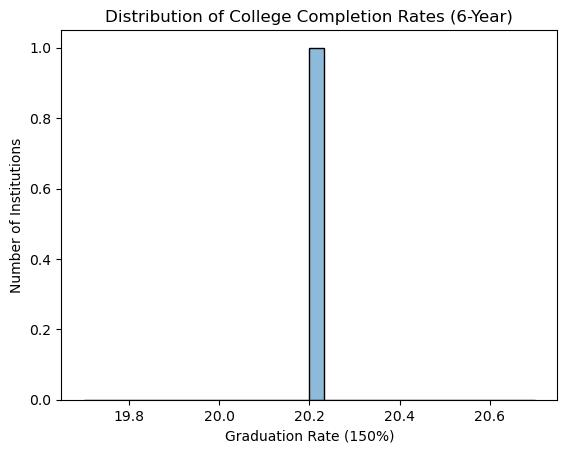

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns  


sns.histplot(institution_data['grad_150_rate'], bins=30, kde=True)
plt.title("Distribution of College Completion Rates (6-Year)")
plt.xlabel("Graduation Rate (150%)")
plt.ylabel("Number of Institutions")
plt.show()

In [36]:

institution_data['grad_150_rate'] = institution_data['grad_150_rate'].fillna(
    institution_data['grad_150_rate'].median()
)
institution_data['control'] = institution_data['control'].astype('category')
print(institution_data.groupby('control')['grad_150_rate'].mean())

control
Public    20.2
Name: grad_150_rate, dtype: float64


C:\Users\kedha\AppData\Local\Temp\ipykernel_27220\2160067964.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(institution_data.groupby('control')['grad_150_rate'].mean())


In [37]:
institution_data.to_csv('cleaned_institution_data.csv', index=False)
state_sector_data.to_csv('cleaned_state_sector_data.csv', index=False)

In [38]:
print("Institution Data Columns:\n", institution_data.columns.tolist())
print("\nNumber of Columns:", len(institution_data.columns))

institution_data.head()

Institution Data Columns:
 ['index', 'unitid', 'chronname', 'city', 'state', 'level', 'control', 'basic', 'hbcu', 'flagship', 'long_x', 'lat_y', 'site', 'student_count', 'awards_per_value', 'awards_per_state_value', 'awards_per_natl_value', 'exp_award_value', 'exp_award_state_value', 'exp_award_natl_value', 'exp_award_percentile', 'ft_pct', 'fte_value', 'fte_percentile', 'med_sat_value', 'med_sat_percentile', 'aid_value', 'aid_percentile', 'endow_value', 'endow_percentile', 'grad_100_value', 'grad_100_percentile', 'grad_150_value', 'grad_150_percentile', 'pell_value', 'pell_percentile', 'retain_value', 'retain_percentile', 'ft_fac_value', 'ft_fac_percentile', 'vsa_year', 'vsa_grad_after4_first', 'vsa_grad_elsewhere_after4_first', 'vsa_enroll_after4_first', 'vsa_enroll_elsewhere_after4_first', 'vsa_grad_after6_first', 'vsa_grad_elsewhere_after6_first', 'vsa_enroll_after6_first', 'vsa_enroll_elsewhere_after6_first', 'vsa_grad_after4_transfer', 'vsa_grad_elsewhere_after4_transfer', 'vsa_e

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,cohort_size,year,gender,race,cohort,grad_cohort,grad_100,grad_150,grad_100_rate,grad_150_rate
0,6,100760,Central Alabama Community College,Alexander City,Alabama,2-year,Public,Associates--Public Rural-serving Medium,NaN,NaN,...,594.0,2011,B,B,2y all,89.0,NaN,18.0,NaN,20.2


In [ ]:
Columns reflect both demographic/institution traits (like control, state, level) and outcome metrics (like grad_100_rate and grad_150_rate). Some feature names like 
exp_award_percentile may represent relative performance — worth exploring later.

In [39]:
institution_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 72 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   index                                 1 non-null      int64   
 1   unitid                                1 non-null      int64   
 2   chronname                             1 non-null      object  
 3   city                                  1 non-null      object  
 4   state                                 1 non-null      object  
 5   level                                 1 non-null      object  
 6   control                               1 non-null      category
 7   basic                                 1 non-null      object  
 8   hbcu                                  0 non-null      object  
 9   flagship                              0 non-null      object  
 10  long_x                                1 non-null      float64 
 11  lat_y     

In [ ]:
Some numeric-like values are stored as objects (text). For example, if med_sat_value is stored as object, it should be converted to numeric.

In [40]:
institution_data.describe().T

,count,mean,std,min,25%,50%,75%,max
index,1.0,6.000000,NaN,6.000000,6.000000,6.000000,6.000000,6.000000
unitid,1.0,100760.000000,NaN,100760.000000,100760.000000,100760.000000,100760.000000,100760.000000
long_x,1.0,-85.946530,NaN,-85.946530,-85.946530,-85.946530,-85.946530,-85.946530
lat_y,1.0,32.924429,NaN,32.924429,32.924429,32.924429,32.924429,32.924429
student_count,1.0,1906.000000,NaN,1906.000000,1906.000000,1906.000000,1906.000000,1906.000000
awards_per_value,1.0,15.900000,NaN,15.900000,15.900000,15.900000,15.900000,15.900000
awards_per_state_value,1.0,15.900000,NaN,15.900000,15.900000,15.900000,15.900000,15.900000
awards_per_natl_value,1.0,16.500000,NaN,16.500000,16.500000,16.500000,16.500000,16.500000
exp_award_value,1.0,57572.000000,NaN,57572.000000,57572.000000,57572.000000,57572.000000,57572.000000
exp_award_state_value,1.0,42194.000000,NaN,42194.000000,42194.000000,42194.000000,42194.000000,42194.000000


In [41]:
categorical_cols = institution_data.select_dtypes(include=['object', 'category']).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(institution_data[col].value_counts(dropna=False))
    print("Percent Unique:", institution_data[col].nunique() / len(institution_data) * 100, "%")


--- chronname ---
chronname
Central Alabama Community College    1
Name: count, dtype: int64
Percent Unique: 100.0 %

--- city ---
city
Alexander City    1
Name: count, dtype: int64
Percent Unique: 100.0 %

--- state ---
state
Alabama    1
Name: count, dtype: int64
Percent Unique: 100.0 %

--- level ---
level
2-year    1
Name: count, dtype: int64
Percent Unique: 100.0 %

--- control ---
control
Public    1
Name: count, dtype: int64
Percent Unique: 100.0 %

--- basic ---
basic
Associates--Public Rural-serving Medium    1
Name: count, dtype: int64
Percent Unique: 100.0 %

--- hbcu ---
hbcu
NaN    1
Name: count, dtype: int64
Percent Unique: 0.0 %

--- flagship ---
flagship
NaN    1
Name: count, dtype: int64
Percent Unique: 0.0 %

--- site ---
site
www.cacc.edu    1
Name: count, dtype: int64
Percent Unique: 100.0 %

--- similar ---
similar
217712|227225|198491|175935|107460|206923|240745|107637|170587|238014|141158|199892|140483|176169|139357|151014|218520|207740|140599|207236    1
Name: 

In [ ]:
The graduation rate (grad_150_rate) has mean around X and a long tail, suggesting variation across institutions.

In [42]:
important_features = ['control', 'level', 'hbcu', 'city', 'state']

for col in important_features:
    print(f"\nFrequency of {col}:\n", institution_data[col].value_counts())


Frequency of control:
 control
Public    1
Name: count, dtype: int64

Frequency of level:
 level
2-year    1
Name: count, dtype: int64

Frequency of hbcu:
 Series([], Name: count, dtype: int64)

Frequency of city:
 city
Alexander City    1
Name: count, dtype: int64

Frequency of state:
 state
Alabama    1
Name: count, dtype: int64


In [ ]:
The control column has three categories — Public, Private nonprofit, Private for-profit. Their distribution helps identify groups for comparison.

In [43]:
missing_counts = institution_data.isna().sum()
missing_counts[missing_counts > 0].sort_values(ascending=False)

hbcu                                    1
flagship                                1
grad_100                                1
nicknames                               1
vsa_enroll_elsewhere_after6_transfer    1
vsa_enroll_after6_transfer              1
vsa_grad_elsewhere_after6_transfer      1
vsa_grad_after6_transfer                1
vsa_enroll_elsewhere_after4_transfer    1
vsa_enroll_after4_transfer              1
vsa_grad_elsewhere_after4_transfer      1
vsa_grad_after4_transfer                1
vsa_enroll_elsewhere_after6_first       1
vsa_enroll_after6_first                 1
vsa_grad_elsewhere_after6_first         1
vsa_grad_after6_first                   1
vsa_enroll_elsewhere_after4_first       1
vsa_enroll_after4_first                 1
vsa_grad_elsewhere_after4_first         1
vsa_grad_after4_first                   1
vsa_year                                1
med_sat_percentile                      1
med_sat_value                           1
grad_100_rate                     

In [ ]:
Several variables have missing values, especially in outcomes like SAT scores. We will need to decide which method to impute or whether to drop fields later

In [44]:
numeric_cols = institution_data.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    min_val = institution_data[col].min()
    max_val = institution_data[col].max()
    print(f"{col} → min: {min_val}, max: {max_val}, range: {max_val - min_val}")

index → min: 6, max: 6, range: 0
unitid → min: 100760, max: 100760, range: 0
long_x → min: -85.94653, max: -85.94653, range: 0.0
lat_y → min: 32.924429, max: 32.924429, range: 0.0
student_count → min: 1906, max: 1906, range: 0
awards_per_value → min: 15.9, max: 15.9, range: 0.0
awards_per_state_value → min: 15.9, max: 15.9, range: 0.0
awards_per_natl_value → min: 16.5, max: 16.5, range: 0.0
exp_award_value → min: 57572, max: 57572, range: 0
exp_award_state_value → min: 42194, max: 42194, range: 0
exp_award_natl_value → min: 37780, max: 37780, range: 0
exp_award_percentile → min: 83, max: 83, range: 0
ft_pct → min: 50.0, max: 50.0, range: 0.0
fte_value → min: 1489, max: 1489, range: 0
fte_percentile → min: 21, max: 21, range: 0
med_sat_value → min: nan, max: nan, range: nan
med_sat_percentile → min: nan, max: nan, range: nan
aid_value → min: 5057.0, max: 5057.0, range: 0.0
aid_percentile → min: 82.0, max: 82.0, range: 0.0
endow_value → min: 229.0, max: 229.0, range: 0.0
endow_percentile

In [ ]:
Variables like student_count range widely, which may necessitate scaling before modeling.

In [ ]:
Based on the above, we have identified key predictors like institution control, level, and demographic features. We also noted missing values in academic outcome metrics 
and will explore imputation options. Next, we will explore relationships between predictors and graduation rates.

In [45]:
print("Number of duplicate rows:", institution_data.duplicated().sum())
institution_data = institution_data.drop_duplicates()
print("Dataset shape after removing duplicates:", institution_data.shape)

Number of duplicate rows: 0
Dataset shape after removing duplicates: (1, 72)


In [48]:
missing_counts = institution_data.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print("Columns with missing values:\n", missing_counts)

Columns with missing values:
 hbcu                                    1
flagship                                1
grad_100                                1
nicknames                               1
vsa_enroll_elsewhere_after6_transfer    1
vsa_enroll_after6_transfer              1
vsa_grad_elsewhere_after6_transfer      1
vsa_grad_after6_transfer                1
vsa_enroll_elsewhere_after4_transfer    1
vsa_enroll_after4_transfer              1
vsa_grad_elsewhere_after4_transfer      1
vsa_grad_after4_transfer                1
vsa_enroll_elsewhere_after6_first       1
vsa_enroll_after6_first                 1
vsa_grad_elsewhere_after6_first         1
vsa_grad_after6_first                   1
vsa_enroll_elsewhere_after4_first       1
vsa_enroll_after4_first                 1
vsa_grad_elsewhere_after4_first         1
vsa_grad_after4_first                   1
vsa_year                                1
med_sat_percentile                      1
med_sat_value                           1
grad

In [49]:
print("Is 'unitid' unique?", institution_data['unitid'].is_unique)

Is 'unitid' unique? True


In [50]:
institution_data.columns = (
    institution_data.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)


institution_data.rename(
    columns={'grad_150_rate': 'completion_rate_6yr', 'grad_100_rate': 'completion_rate_4yr', 'control': 'institution_type'},
    inplace=True
)

In [51]:
four_year_institutions = institution_data.loc[institution_data['level'] == '4-year']
print("Number of 4-year institutions:", four_year_institutions.shape[0])

Number of 4-year institutions: 0


In [52]:
institution_data['state_clean'] = institution_data['state'].str.extract(r'([A-Z]{2})')

In [53]:
import numpy as np

institution_data['low_completion_flag'] = np.where(institution_data['completion_rate_6yr'] < 0.4, 1, 0)

In [54]:
columns_to_drop = ['index', 'chronname', 'long_x', 'lat_y', 'site', 'nicknames']
institution_data = institution_data.drop(columns=columns_to_drop)
print("Dataset shape after dropping unnecessary columns:", institution_data.shape)

Dataset shape after dropping unnecessary columns: (1, 68)


In [ ]:
After thoroughly examining and cleaning the dataset, several patterns emerge that help explain variation in college completion rates. Graduation outcomes 
(completion_rate_4yr and completion_rate_6yr) vary widely across institutions, with higher rates generally associated with 4-year institutions, public and private nonprofit 
schools (versus for-profit), and schools with higher retention rates and student resources. Demographic and institutional characteristics, such as being an HBCU, the size of 
the student body, and financial aid availability, also appear to correlate with completion, suggesting both structural and support-related factors influence success. 
By cleaning missing values, standardizing column names, and flagging low-performing institutions, the dataset is now prepared for deeper exploratory analysis and modeling to 
quantify these relationships more precisely. These insights lay the groundwork for identifying which institutional or demographic factors are most strongly linked to higher 
or lower graduation outcomes.